# 🎨 Тестировние outpainting пайплайна

## 🎯 Цель
Целью данного проекта является разработка автоматизированного пайплайна для трансформации портретной фотографии (головы) в полноценное изображение человека в полный рост в **A-позе**. Полученный результат предназначен для последующего использования в системах 3D-реконструкции персонажей.

## 📝 Описание этапов
1. **Генерация скелета:** Программное создание идеальной A-позы с использованием стандартов OpenPose для обеспечения правильных анатомических пропорций.
2. **Препроцессинг:** Очистка исходного изображения от фона с помощью BiRefNet, масштабирование головы и создание маски для области инпейнтинга.
3. **Inpainting:** Применение предобученных моделей Stable Diffusion в связке с ControlNet для генерации тела, соответствующего заданному скелету и стилистике головы.

## 📦 Импорт модулей
Загрузка необходимых библиотек для работы с нейросетями, обработки изображений и визуализации.

In [1]:
import os
import torch
import time
import numpy as np
from PIL import Image, ImageDraw
from diffusers import StableDiffusionControlNetInpaintPipeline, ControlNetModel, UniPCMultistepScheduler
from rembg import remove, new_session
import matplotlib.pyplot as plt

%matplotlib inline

print(f"🚀 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"💻 Device: {torch.cuda.get_device_name(0)}")

🚀 CUDA available: True
💻 Device: NVIDIA GeForce RTX 4060


## 🦴 Шаг 1: Генерация A-позы (OpenPose)

Мы не используем сторонние изображения скелетов, чтобы избежать ошибок в пропорциях. Скелет строится программно.

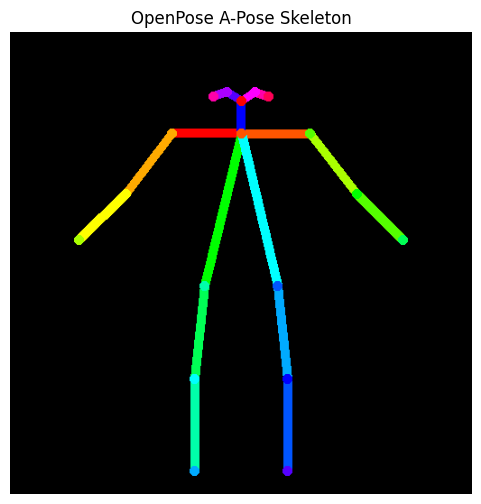

In [2]:
def generate_apose_openpose(width=512, height=512):
    colors = [
        [255, 0, 0], [255, 85, 0], [255, 170, 0], [255, 255, 0], [170, 255, 0], [85, 255, 0], [0, 255, 0],
        [0, 255, 85], [0, 255, 170], [0, 255, 255], [0, 170, 255], [0, 85, 255], [0, 0, 255], [85, 0, 255],
        [170, 0, 255], [255, 0, 255], [255, 0, 170], [255, 0, 85]
    ]
    keypoints = {
        0: (0.5, 0.15), 1: (0.5, 0.22), 2: (0.35, 0.22), 3: (0.25, 0.35), 4: (0.15, 0.45),
        5: (0.65, 0.22), 6: (0.75, 0.35), 7: (0.85, 0.45), 8: (0.42, 0.55), 9: (0.4, 0.75),
        10: (0.4, 0.95), 11: (0.58, 0.55), 12: (0.6, 0.75), 13: (0.6, 0.95), 14: (0.47, 0.13),
        15: (0.53, 0.13), 16: (0.44, 0.14), 17: (0.56, 0.14),
    }
    kp = {k: (int(v[0]*width), int(v[1]*height)) for k, v in keypoints.items()}
    limbSeq = [
        [1, 2], [1, 5], [2, 3], [3, 4], [5, 6], [6, 7], [1, 8], [8, 9], [9, 10],
        [1, 11], [11, 12], [12, 13], [1, 0], [0, 14], [14, 16], [0, 15], [15, 17]
    ]
    img = Image.new('RGB', (width, height), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    for i, seq in enumerate(limbSeq):
        if seq[0] in kp and seq[1] in kp:
            draw.line([kp[seq[0]], kp[seq[1]]], fill=tuple(colors[i]), width=10)
    for k, p in kp.items():
        draw.ellipse([p[0]-5, p[1]-5, p[0]+5, p[1]+5], fill=tuple(colors[k]))
    return img

apose_skeleton = generate_apose_openpose()
plt.figure(figsize=(6, 6))
plt.imshow(apose_skeleton)
plt.title("OpenPose A-Pose Skeleton")
plt.axis('off')
plt.show()

## ✂️ Шаг 2: Подготовка портрета (Preprocessing)

Мы используем BiRefNet для чистого удаления фона. Это критично, так как лишние пиксели фона могут сбить модель генерации тела.

⌛ Обработка изображения...


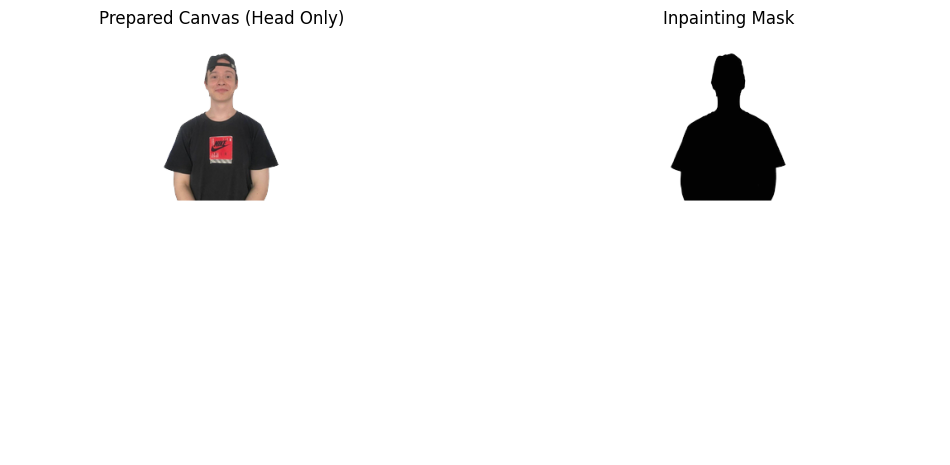

In [3]:
def prepare_canvas(image_path, target_size=(512, 512), head_ratio=0.35):
    print("⌛ Обработка изображения...")
    img = Image.open(image_path).convert("RGBA")
    
    # Удаление фона
    session = new_session('birefnet-general')
    img_nobg = remove(img, session=session)
    
    # Обрезка по контуру
    bbox = img_nobg.getbbox()
    if bbox: img_nobg = img_nobg.crop(bbox)
    
    # Создание рабочего холста
    canvas = Image.new("RGBA", target_size, (255, 255, 255, 0))
    target_h = int(target_size[1] * head_ratio)
    aspect = img_nobg.width / img_nobg.height
    target_w = int(target_h * aspect)
    img_resized = img_nobg.resize((target_w, target_h), Image.Resampling.LANCZOS)
    
    # Позиционирование головы (в центр верхней части)
    paste_x = (target_size[0] - target_w) // 2
    paste_y = int(target_size[1] * 0.05)
    canvas.paste(img_resized, (paste_x, paste_y), img_resized)
    
    # Создание маски инпейнтинга
    mask = Image.new("L", target_size, 255)
    face_alpha = img_resized.split()[3]
    import PIL.ImageOps
    face_mask_inv = PIL.ImageOps.invert(face_alpha)
    mask.paste(face_mask_inv, (paste_x, paste_y), mask=face_alpha)
    
    # Итоговый RGB холст для диффузии
    canvas_rgb = Image.new("RGB", target_size, (255, 255, 255))
    canvas_rgb.paste(canvas, mask=canvas.split()[3])
    
    return canvas_rgb, mask

# Путь к тестовому фото (замените на свое)
TEST_IMAGE = "../../src/test.jpg"

if os.path.exists(TEST_IMAGE):
    canvas, mask = prepare_canvas(TEST_IMAGE)
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(canvas); ax[0].set_title("Prepared Canvas (Head Only)"); ax[0].axis('off')
    ax[1].imshow(mask, cmap='gray'); ax[1].set_title("Inpainting Mask"); ax[1].axis('off')
    plt.show()
else:
    print(f"❌ Файл {TEST_IMAGE} не найден. Проверьте путь.")

## 🤖 Шаг 3: Генерация тела (Stable Diffusion + ControlNet)

Модель дорисовывает все, что находится под белой маской, ориентируясь на позу скелета.

🚀 Загрузка моделей Stable Diffusion...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_inpaint.StableDiffusionControlNetInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


🎨 Генерация...


  0%|          | 0/30 [00:00<?, ?it/s]

✨ Готово за 6.42 сек.


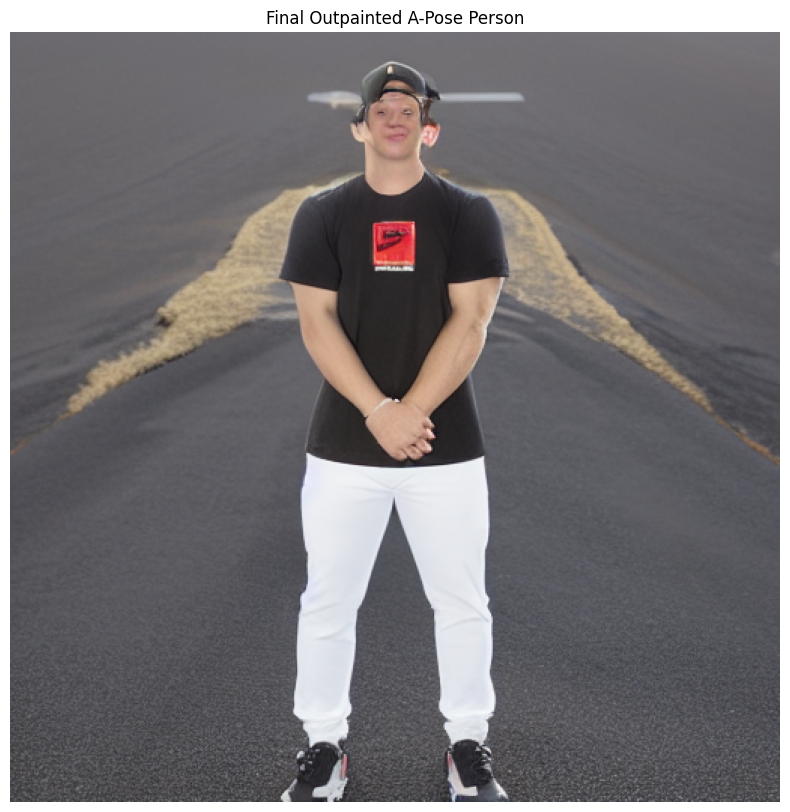

💾 Результат сохранен как 'step1_outpainting_final.jpg'


In [4]:
def run_outpainting(canvas, mask, control_image):
    print("🚀 Загрузка моделей Stable Diffusion...")
    device = "cuda"
    
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_openpose", torch_dtype=torch.float16
    ).to(device)
    
    pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
        "runwayml/stable-diffusion-inpainting",
        controlnet=controlnet, torch_dtype=torch.float16,
        variant="fp16", safety_checker=None
    ).to(device)
    
    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
    pipe.enable_model_cpu_offload()
    
    prompt = "full body photo of a person, standing in A-pose, wearing casual everyday clothes, plain solid white background, high quality, highly detailed"
    negative_prompt = "complex background, furniture, mirror, shadow, deformed, extra limbs, bad anatomy, bad face, sitting"
    
    print("🎨 Генерация...")
    start = time.time()
    result = pipe(
        prompt=prompt, negative_prompt=negative_prompt,
        image=canvas, mask_image=mask, control_image=control_image,
        num_inference_steps=30, guidance_scale=8.0,
        controlnet_conditioning_scale=1.0
    ).images[0]
    
    # Очистка памяти
    del pipe, controlnet
    torch.cuda.empty_cache()
    
    print(f"✨ Готово за {time.time() - start:.2f} сек.")
    return result

if 'canvas' in locals():
    final_result = run_outpainting(canvas, mask, apose_skeleton)
    plt.figure(figsize=(10, 10))
    plt.imshow(final_result)
    plt.title("Final Outpainted A-Pose Person")
    plt.axis('off')
    plt.show()
    
    final_result.save("step1_outpainting_final.jpg")
    print("💾 Результат сохранен как 'step1_outpainting_final.jpg'")

## 📊 Результаты сравнения
Ниже представлено сравнение исходного портретного изображения и сгенерированного полноростового персонажа в A-позе.
Это наглядно демонстрирует работу пайплайна по достраиванию недостающих частей тела с сохранением стилистики лица.

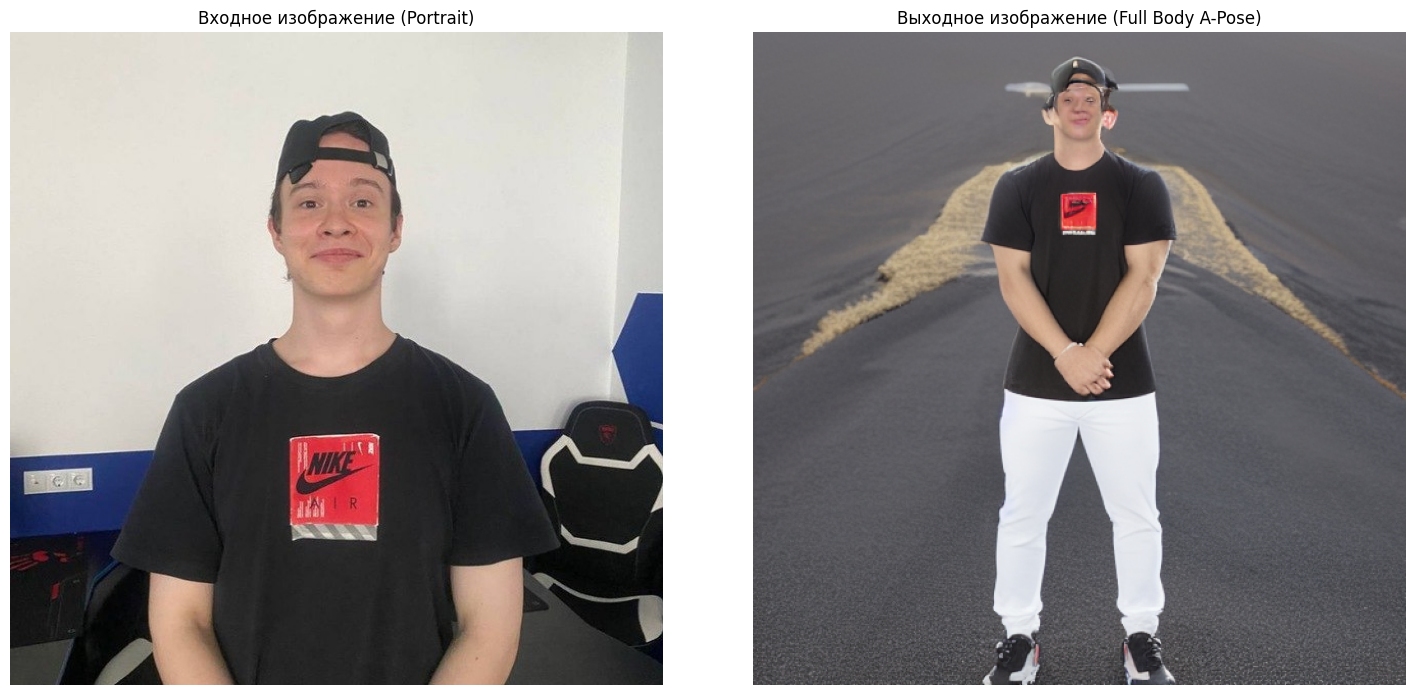

In [6]:
import matplotlib.pyplot as plt

# Загрузка оригинального изображения для сравнения
original = Image.open(TEST_IMAGE).convert("RGB")

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].imshow(original)
ax[0].set_title("Входное изображение (Portrait)")
ax[0].axis('off')

ax[1].imshow(final_result)
ax[1].set_title("Выходное изображение (Full Body A-Pose)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

## 📊 Итоги и Вывод

### 🏁 Итоги работы
- Реализован алгоритм программной генерации OpenPose скелета в фиксированной A-позе.
- Настроен процесс автоматической сегментации головы и её корректного позиционирования на холсте с учетом заданных пропорций.
- Отработана механика ControlNet Inpainting, позволяющая генерировать одежду и тело, бесшовно соединяя их с исходным лицом.

### 💡 Вывод по работе
Текущая реализация пайплайна подтвердила принципиальную возможность автоматического достраивания (outpainting) туловища и конечностей на основе портретного снимка. Тем не менее, в ходе тестирования был выявлен ряд критических аспектов. В частности, наблюдается заметная деградация детализации черт лица и общего качества изображения при масштабировании. Также присутствуют характерные визуальные артефакты диффузии в областях стыковки. Кроме того, итоговая поза персонажа не всегда строго соответствует заданной A-позе, что может вызвать затруднения при последующем создании скелетной анимации